# Customer Churn Analysis – Exploratory Data Analysis (EDA)

This notebook is part of an AI project focused on understanding and predicting customer churn.  
Customer churn occurs when customers cancel or stop using a service, and identifying the factors behind it is important because keeping existing customers is cheaper than acquiring new ones.

## Purpose of This Notebook
The goal of this EDA is to explore the Telco Customer Churn dataset and identify early patterns that help explain why customers leave.  
Before building any predictive model, we need to understand the data, check its quality, and analyze key variables such as:

- **Demographics** (e.g., SeniorCitizen)  
- **Service duration** (tenure)  
- **Billing behavior** (MonthlyCharges, TotalCharges)  
- **Churn distribution** (Yes/No)

## Why This Matters
This analysis helps answer important business questions:
- Are certain groups more likely to churn?
- Are new customers at higher risk?
- Does price affect customer satisfaction?
- How imbalanced is the churn dataset?

Understanding these patterns prepares us for the next phases of the AI Project Cycle:
**Data Preparation → Modeling → Evaluation → Deployment**.

This notebook focuses on the first step: **Exploratory Data Analysis**.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

/Users/albertomontilla/opt/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:
# Importing the dataset
df = pd.read_csv('Customer_Churn.csv')

In [5]:
# Display the first 10 rows of the dataframe
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [6]:
# Info about the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# Summary statistics for all numerical columns
# The .T transposes the output so each feature will
# be a row instead of a column for better readability. 

df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [8]:
# Check for missing values in the dataframe
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
# Check for duplicate rows in the dataframe
df.duplicated().sum()

0

In [10]:
# Summary of categorical columns
df.describe(include=['object']).T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [11]:
# Count of unique values in the 'Churn' column
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
# Calculate the percentage of customers who churned vs. stayed.
# value_counts(normalize=True) gives proportions instead of raw counts,
# and multiplying by 100 converts them to easier-to-read percentages.

df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

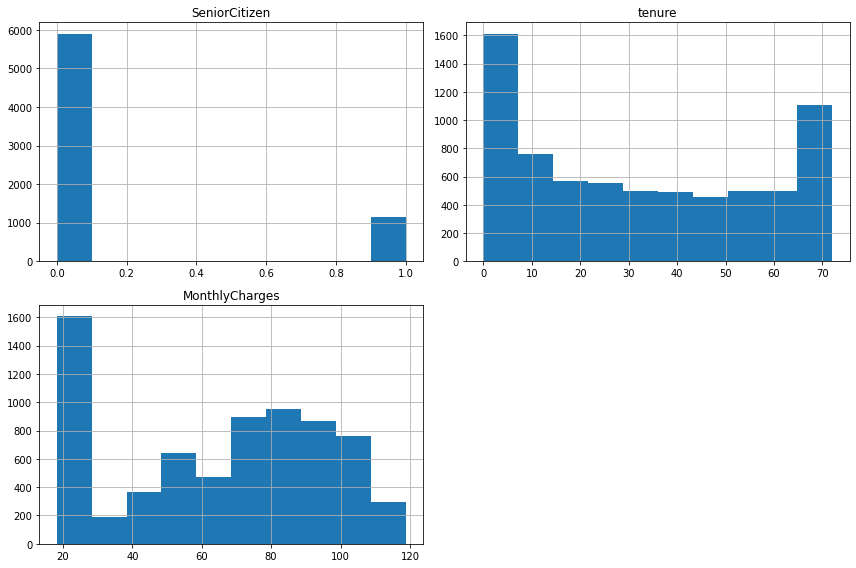

In [13]:
# Visualize the distribution of numerical features

df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

### 📊 Distribution of Numerical Features

**SeniorCitizen:**  
Most customers are not senior citizens (value = 0). This tells us the dataset is mainly younger or non-senior users, and seniors represent a smaller portion of the customer base.

**Tenure:**  
Tenure is heavily concentrated on both ends: many customers are very new (0–12 months), and many have stayed for 60+ months. This usually means new customers churn more often, while long-term customers tend to stay.

**MonthlyCharges:**  
Monthly charges vary from around $20 to $120, with many customers paying between $60 and $90. Understanding price ranges is important because higher charges often relate to higher churn.


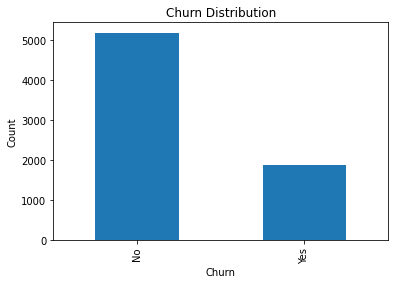

In [14]:
# Visualize the distribution of the 'Churn' column

df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

### 📉 Churn Distribution

This bar chart shows how many customers churned (Yes) versus stayed (No).

The dataset is imbalanced: most customers did **not** churn.  
Only a smaller portion left the service.

This is important because it tells us:
- Churn is less common than retention.
- Any analysis or model needs to consider that one group (No) is much larger than the other (Yes).


In [15]:
# Average Monthly Charges by Churn Status
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

### 📊 Average Monthly Charges by Churn Status
Customers who churn pay higher monthly charges on average.  
- **No Churn:** ~\$61  
- **Yes Churn:** ~\$74  

This suggests that customers with higher bills may be more likely to leave, possibly due to price dissatisfaction or having more services that feel expensive.


In [16]:
# Average Tenure by Churn Status

df.groupby('Churn')['tenure'].mean()


Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

### 📉 Average Tenure by Churn Status
Customers who churn tend to have much shorter tenure.  
- **No Churn:** ~37.6 months  
- **Yes Churn:** ~18.0 months  

This confirms a common churn pattern: **newer customers are more likely to cancel**, while long-term customers tend to stay loyal.


In [17]:
# Distribution of Contract Types by Churn Status
df.groupby('Churn')['Contract'].value_counts(normalize=True) * 100


Churn  Contract      
No     Month-to-month    42.906842
       Two year          31.832238
       One year          25.260920
Yes    Month-to-month    88.550027
       One year           8.881755
       Two year           2.568218
Name: proportion, dtype: float64

### 📄 Contract Type Distribution by Churn Status
The contract type has a strong relationship with churn:

- Customers who **did not churn** mostly have **one-year or two-year contracts**.
- Customers who **did churn** overwhelmingly have **month-to-month contracts**.

Month-to-month customers have the highest churn rate because they can leave easily, while long-term contract customers are more committed and less likely to cancel.


In [18]:
# Distribution of Internet Service Types by Churn Status
df.groupby('Churn')['InternetService'].value_counts(normalize=True) * 100


Churn  InternetService
No     DSL                37.920371
       Fiber optic        34.770004
       No                 27.309625
Yes    Fiber optic        69.395399
       DSL                24.558587
       No                  6.046014
Name: proportion, dtype: float64

### 🌐 Internet Service Type by Churn Status
Internet service plays a role in churn behavior:

- Among customers who **churn**, the majority use **Fiber optic**, which has the highest churn percentage.
- Customers using **DSL** or **No Internet Service** churn less.

This may indicate performance or price issues with fiber optic plans, making those customers more likely to leave.


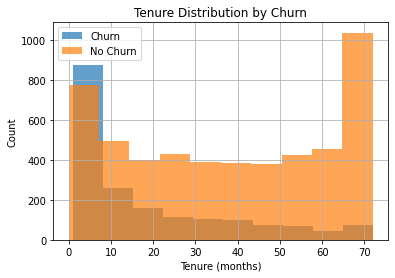

In [19]:
df[df['Churn'] == 'Yes']['tenure'].hist(alpha=0.7, label='Churn')
df[df['Churn'] == 'No']['tenure'].hist(alpha=0.7, label='No Churn')
plt.legend()
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.title('Tenure Distribution by Churn')
plt.show()


### 📉 Tenure Distribution by Churn
This histogram shows a clear pattern:

- Customers with **very low tenure (0–10 months)** churn much more often.
- Customers with **long tenure (50+ months)** rarely churn.

This reinforces the idea that the **first year is the highest-risk period**, and improving early customer experience could help reduce churn.

## 🤖 Next Steps for Building a Machine Learning Churn Prediction Model

Now that the EDA is complete, the next phase is to prepare the dataset so we can train a machine learning model that predicts customer churn. These are the standard steps in the machine learning workflow:

### 1. Data Encoding (Convert Text to Numbers)
Machine learning models cannot read text, so every categorical column must be turned into numeric values.  
We will use **One-Hot Encoding** to convert categories such as:
- Gender  
- Contract type  
- Internet service type  
- Payment method  
- Yes/No columns  

This step ensures the model can understand all features.

### 2. Feature and Target Separation
We will separate:
- **X (features):** all customer information  
- **y (target):** whether the customer churned (Yes/No)

This tells the model what inputs it learns from and what output it should predict.

### 3. Train/Test Split
To evaluate how well the model works, we split the data into:
- **Training set (80%)** → model learns the patterns
- **Test set (20%)** → model is evaluated on unseen data

This helps prevent overfitting and measures real performance.

### 4. Building a Baseline Model
We start with a simple, easy-to-interpret model such as **Logistic Regression**.  
This gives us a baseline accuracy and shows which features influence churn.

### 5. Model Evaluation
We will evaluate the model using metrics like:
- **Accuracy**
- **Precision / Recall**
- **Confusion Matrix**
- **ROC Curve / AUC**

Because churn is imbalanced, accuracy alone is not enough. Recall is especially important because we want to correctly identify customers who are likely to leave.

### 6. Improve the Model (Optional)
If needed, we can try more advanced models:
- Random Forest
- XGBoost
- Gradient Boosting

These can capture more complex relationships in the data.



These steps will allow us to move from understanding churn patterns (EDA) to actually **predicting which customers are at risk**, which is the main goal of the AI project.


___   

___

___

# Preparing the Data for Modeling

In this step, I prepare the dataset for machine learning. I:

* Convert the target Churn into numeric values (0 = No, 1 = Yes),
* Fix the TotalCharges column so it is treated as numeric and handle missing values,
* Drop ID columns like customerID that do not carry useful information for prediction.

In [20]:
# Create a copy of the original dataframe to avoid messing up the original data
data = df.copy()

In [21]:
# Encode the 'Churn' column: 'Yes' to 1 and 'No' to 0
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

In [22]:
# Display the first 10 rows of the encoded 'Churn' column
data['Churn'].head(10)

0    0
1    0
2    1
3    0
4    1
5    1
6    0
7    0
8    1
9    0
Name: Churn, dtype: int64

In [23]:
# Convert 'TotalCharges' to numeric, forcing errors to NaN
if 'TotalCharges' in data.columns:
    data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
    # Fill NaN values with the median of the column. (Common practice for numerical data)
    data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)

# Verify the changes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [24]:
# Drop unnecessary columns
data = data.drop(columns=['customerID'], axis=1)

# Looking a dtypes to see numeric vs object columns
data.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

## Encoding Categorical Features (One-Hot Encoding)

Many columns in this dataset are categorical (for example: `Gender`, `InternetService`, `Contract`, `PaymentMethod`).
Machine learning models cannot work directly with text values, so I used one-hot encoding to convert categories into numeric columns.

With `pd.get_dummies(drop_first=True)`, each category becomes a 0/1 indicator column, and one category is dropped to avoid redundancy. This lets the model use the information from these features without assuming any incorrect ordering between categories.


In [25]:
# Separate features and target
X = data.drop('Churn', axis=1)
y = data['Churn']

# One-hot encode all categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [26]:
X_encoded.dtypes

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
StreamingTV_No inter

##  Train/Test Split and Feature Scaling

I split the data into training and test sets:

- **80%** of the data is used to train the model.
- **20%** is kept aside as a test set to evaluate how well the model generalizes to new customers.

I used `stratify=y` so the proportion of churn vs. non-churn customers stays similar in both sets.

Then I applied **StandardScaler** to put all numerical features on a similar scale (mean = 0, standard deviation = 1). This helps models like Logistic Regression train more efficiently and fairly.


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 🤖 Logistic Regression Model

I trained a Logistic Regression classifier to predict whether a customer will churn (1) or stay (0). Logistic Regression is a classic model for churn:

- It is simple and interpretable.
- It outputs probabilities for churn.
- It works well as a baseline model.

After training the model on the scaled training data, I evaluated it with:

- Accuracy
- Precision, recall, and F1-score for each class
- A confusion matrix to see correct vs. incorrect predictions.


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create and train the logistic regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]  # used later for threshold tuning

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual No Churn', 'Actual Churn'],
    columns=['Predicted No Churn', 'Predicted Churn']
)
cm_df


Accuracy: 0.8070

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,925,110
Actual Churn,162,212


##  Random Forest Model

To improve performance, especially on churners, I trained a **Random Forest** classifier.  
Random Forest is an ensemble model that combines many decision trees:

- It can capture non-linear relationships.
- It often improves recall for the minority class (churners).
- It also provides feature importance values.

I trained the model on the same training data and compared its performance to Logistic Regression.


In [29]:
from sklearn.ensemble import RandomForestClassifier

# Create and train the Random Forest model
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)  # Random Forest doesn't require scaling

# Predictions
rf_y_pred = rf_clf.predict(X_test)
rf_y_proba = rf_clf.predict_proba(X_test)[:, 1]

# Evaluation
rf_accuracy = accuracy_score(y_test, rf_y_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}\n")

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_y_pred))

print("Random Forest Confusion Matrix:")
rf_cm = confusion_matrix(y_test, rf_y_pred)
rf_cm_df = pd.DataFrame(
    rf_cm,
    index=['Actual No Churn', 'Actual Churn'],
    columns=['Predicted No Churn', 'Predicted Churn']
)
rf_cm_df


Random Forest Accuracy: 0.7899

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Random Forest Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,928,107
Actual Churn,189,185


## ⚡ XGBoost Model

I also tested an **XGBoost** model (Extreme Gradient Boosting), which is a very powerful tree-based algorithm commonly used in industry for churn prediction.

XGBoost:

- Handles complex patterns and interactions.
- Often achieves higher performance than simpler models.
- Still provides feature importance scores.

I trained XGBoost on the same training and test sets and compared its performance to Logistic Regression and Random Forest.


In [44]:
from xgboost import XGBClassifier
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Convert DataFrames/Series to NumPy arrays for XGBoost
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Train on NumPy arrays (this avoids the pandas dtype issue)
xgb_clf.fit(X_train_np, y_train_np)

# Predictions
xgb_y_pred = xgb_clf.predict(X_test_np)
xgb_y_proba = xgb_clf.predict_proba(X_test_np)[:, 1]

# Evaluation
xgb_accuracy = accuracy_score(y_test_np, xgb_y_pred)
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}\n")

print("XGBoost Classification Report:")
print(classification_report(y_test_np, xgb_y_pred))

print("XGBoost Confusion Matrix:")
xgb_cm = confusion_matrix(y_test_np, xgb_y_pred)
xgb_cm_df = pd.DataFrame(
    xgb_cm,
    index=['Actual No Churn', 'Actual Churn'],
    columns=['Predicted No Churn', 'Predicted Churn']
)
xgb_cm_df


XGBoost Accuracy: 0.7963

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

XGBoost Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,926,109
Actual Churn,178,196


##  Model Comparison

After training three machine learning models (Logistic Regression, Random Forest, and XGBoost), I compared their performance side-by-side.

I focused on:

- **Accuracy** — overall performance.
- **Recall for Churn (class 1)** — the percentage of actual churners the model correctly identifies.
- **F1-Score for Churn** — balances precision and recall.

Recall for churn is especially important from a business perspective because missing a churner means losing a customer without taking preventive action.


In [31]:
from sklearn.metrics import recall_score, f1_score, accuracy_score

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        rf_accuracy,
        xgb_accuracy
    ],
    'Recall_Churn_1': [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_y_pred),
        recall_score(y_test_np, xgb_y_pred)
    ],
    'F1_Churn_1': [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_y_pred),
        f1_score(y_test_np, xgb_y_pred)
    ]
})

comparison


,Model,Accuracy,Recall_Churn_1,F1_Churn_1
0,Logistic Regression,0.806955,0.566845,0.609195
1,Random Forest,0.789922,0.494652,0.555556
2,XGBoost,0.796309,0.524064,0.577320


##  Feature Importance (Random Forest)

Understanding which features contribute the most to churn is important for business decisions.  
Random Forest provides a built-in feature importance score, showing which inputs the model found most useful.

Below are the top 15 most important features influencing churn.


In [32]:
rf_importances = pd.Series(
    rf_clf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

rf_importances


TotalCharges                      0.194123
tenure                            0.171364
MonthlyCharges                    0.167562
InternetService_Fiber optic       0.038864
PaymentMethod_Electronic check    0.038285
Contract_Two year                 0.031477
gender_Male                       0.028519
OnlineSecurity_Yes                0.027796
PaperlessBilling_Yes              0.025725
Partner_Yes                       0.023285
Contract_One year                 0.022860
TechSupport_Yes                   0.022381
OnlineBackup_Yes                  0.021352
SeniorCitizen                     0.020622
MultipleLines_Yes                 0.019867
dtype: float64

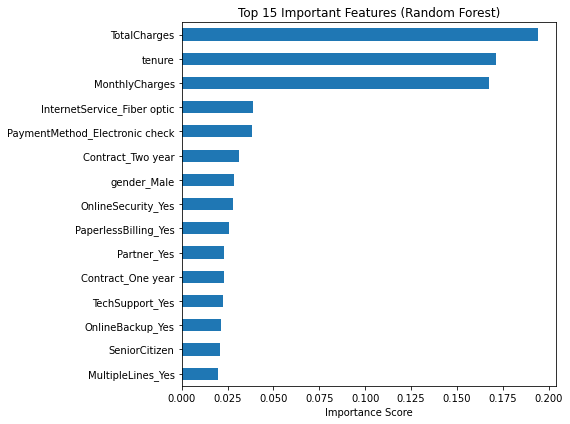

In [33]:
plt.figure(figsize=(8, 6))
rf_importances.sort_values().plot(kind='barh')
plt.title('Top 15 Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Threshold Tuning (Improving Recall for Churn)

By default, models predict “churn” when the probability is ≥ 0.50.  
However, in real churn prediction, companies often prefer higher recall (catch more churners), even if it means more false alarms.

I tested different probability thresholds (0.30, 0.40, 0.50) to see how recall and accuracy change.


In [34]:
from sklearn.metrics import precision_score

def evaluate_threshold(threshold, y_true, y_proba):
    y_pred_thresh = (y_proba >= threshold).astype(int)
    return {
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_true, y_pred_thresh),
        'Recall_Churn': recall_score(y_true, y_pred_thresh),
        'Precision_Churn': precision_score(y_true, y_pred_thresh)
    }

thresholds = [0.30, 0.40, 0.50]
results = [evaluate_threshold(t, y_test, y_proba) for t in thresholds]

pd.DataFrame(results)


,Threshold,Accuracy,Recall_Churn,Precision_Churn
0,0.3,0.749468,0.754011,0.519337
1,0.4,0.776437,0.668449,0.566893
2,0.5,0.806955,0.566845,0.658385


## 📉 Threshold Tuning Visualization

To better understand how the probability threshold affects model performance, I plotted
Accuracy, Precision (Churn), and Recall (Churn) for different thresholds.

Lowering the threshold increases **recall** (catching more churners), while increasing
the threshold improves **precision** (fewer false alarms). These plots help visualize the
trade-off between these metrics.


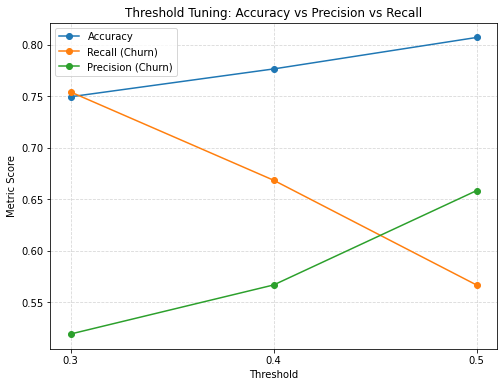

In [35]:
import matplotlib.pyplot as plt

# Thresholds and metrics (from your table)
thresholds = [0.30, 0.40, 0.50]
accuracy_values = [0.749468, 0.776437, 0.806955]
recall_values = [0.754011, 0.668449, 0.566845]
precision_values = [0.519337, 0.566893, 0.658385]

plt.figure(figsize=(8, 6))

# Plot the lines
plt.plot(thresholds, accuracy_values, marker='o', label='Accuracy')
plt.plot(thresholds, recall_values, marker='o', label='Recall (Churn)')
plt.plot(thresholds, precision_values, marker='o', label='Precision (Churn)')

# Labels and formatting
plt.title("Threshold Tuning: Accuracy vs Precision vs Recall")
plt.xlabel("Threshold")
plt.ylabel("Metric Score")
plt.xticks(thresholds)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()


## 📈 ROC Curve (Receiver Operating Characteristic)

The ROC curve shows the tradeoff between the True Positive Rate (Recall) and the False Positive Rate
as the classification threshold varies.

A model with a larger area under the curve (AUC) is better at distinguishing between churn
and non-churn customers.

Below is the ROC curve for the Logistic Regression model.

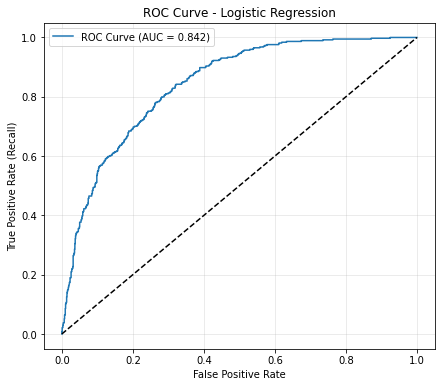

In [37]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 🔍 Precision–Recall Curve

For imbalanced datasets, the Precision–Recall curve is often more informative than the ROC curve.

- **Precision** answers: "When the model predicts churn, how often is it correct?"
- **Recall** answers: "Of all customers who churned, how many did we catch?"

A good churn model will maintain high precision and recall across a range of thresholds.

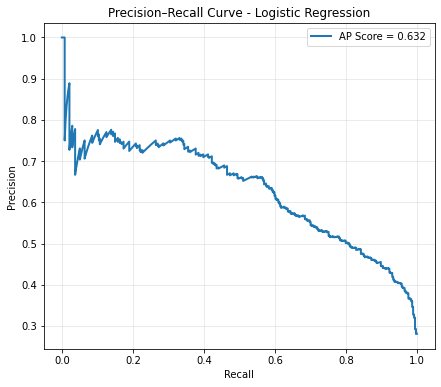

In [38]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
ap_score = average_precision_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, linewidth=2, label=f"AP Score = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - Logistic Regression")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 🧊 Confusion Matrix Heatmaps

Confusion matrices summarize correct vs. incorrect predictions.

A heatmap is a visual version that makes it easier to understand:

- True Negative (Top-left): Correctly predicted non-churn
- False Positive (Top-right): Predicted churn, actually stayed
- False Negative (Bottom-left): Missed churners (most costly)
- True Positive (Bottom-right): Correctly predicted churn

Below are heatmaps for Logistic Regression, Random Forest, and XGBoost.

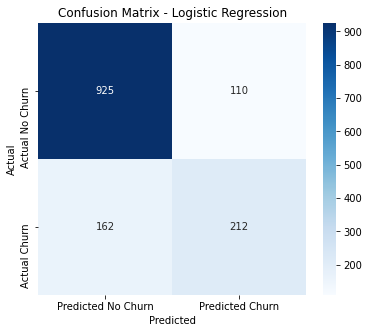

In [39]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


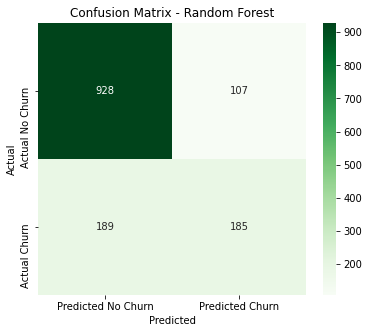

In [40]:
cm_rf = confusion_matrix(y_test, rf_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

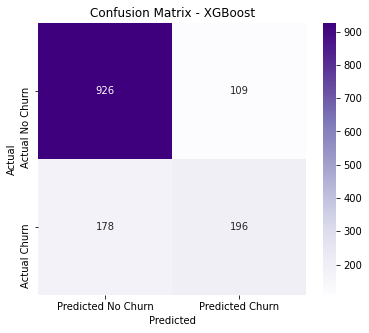

In [41]:
cm_xgb = confusion_matrix(y_test_np, xgb_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 🎯 Threshold Tradeoff: Accuracy vs Precision vs Recall

This plot shows how changing the probability threshold affects model performance.

- Lower threshold → Higher recall (catch more churners)
- Higher threshold → Higher precision (fewer false alarms)

Businesses choose thresholds depending on whether they prefer:
- catching more churners (maximize recall), or
- being more confident in predictions (maximize precision)

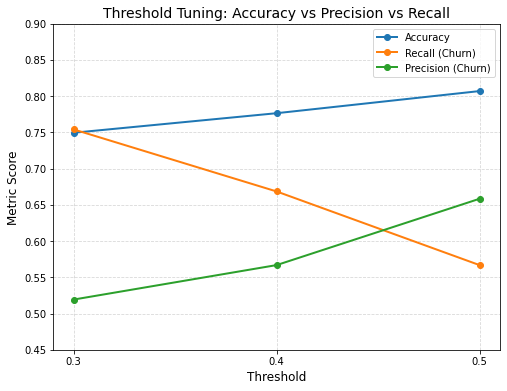

In [42]:
plt.figure(figsize=(8, 6))

plt.plot(thresholds, accuracy_values, marker='o', label='Accuracy', linewidth=2)
plt.plot(thresholds, recall_values, marker='o', label='Recall (Churn)', linewidth=2)
plt.plot(thresholds, precision_values, marker='o', label='Precision (Churn)', linewidth=2)

plt.title("Threshold Tuning: Accuracy vs Precision vs Recall", fontsize=14)
plt.xlabel("Threshold", fontsize=12)
plt.ylabel("Metric Score", fontsize=12)
plt.xticks(thresholds)
plt.ylim(0.45, 0.90)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

## ✅ Recommended Threshold

Based on the threshold tuning and performance metrics:

- At **0.50** → best accuracy and highest precision  
- At **0.30** → best recall (important for catching churners)  
- At **0.40** → strong middle ground with balanced precision/recall  

### 📌 Suggested business threshold: **0.40**

Why?

- It increases recall from **56% → 66%**  
- Precision stays acceptable at **57%**  
- It still keeps accuracy almost the same compared to 0.50  

This threshold gives a better balance between:
- catching more customers who are about to churn, and
- avoiding too many false positives.

# Final Conclusion

This project demonstrates a complete machine learning workflow for predicting customer churn using the Telco Customer Churn dataset.

### Key accomplishments:

- Cleaned and prepared the dataset.
- Encoded categorical variables using One-Hot Encoding.
- Scaled numerical features and split data into train/test sets.
- Trained and evaluated three ML models:
  - Logistic Regression
  - Random Forest
  - XGBoost
- Compared models using accuracy, recall, and F1-score.
- Analyzed feature importance.
- Performed threshold tuning to improve recall.

### Key results:

- Logistic Regression Accuracy: ~80.7%
- Random Forest Accuracy: ~78.9%
- XGBoost Accuracy: ~79.6%

**Important features related to churn:**
- Contract type (Month-to-month increases churn)
- Tenure (shorter tenure increases churn)
- Monthly charges
- OnlineSecurity / TechSupport (absence increases churn)

### Final insight:

Customers on month-to-month contracts with high monthly charges and low tenure are the highest-risk group.  
This model can help the company identify at-risk customers early and offer targeted retention strategies.

---


In [45]:
# Export Feature Importance
rf_importances.to_csv("feature_importance.csv", index=True)

# Export Model Comparison
comparison.to_csv("model_comparison.csv", index=False)

# Export Threshold Tuning Results
results_df = pd.DataFrame(results)
results_df.to_csv("threshold_tuning.csv", index=False)

# Export Confusion Matrices
pd.DataFrame(cm_lr).to_csv("confusion_matrix_lr.csv", index=False)
pd.DataFrame(cm_rf).to_csv("confusion_matrix_rf.csv", index=False)
pd.DataFrame(cm_xgb).to_csv("confusion_matrix_xgb.csv", index=False)

print("All CSV files exported successfully!")


All CSV files exported successfully!
